In [ ]:
# CELL 1: Mount Google Drive
print("📁 Mounting Google Drive...")
from google.colab import drive
drive.mount('/content/drive')
print("✅ Google Drive mounted successfully!")

📁 Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive mounted successfully!


In [ ]:
# CELL 2: Install Required Libraries
print("📦 Installing required libraries...")
!pip install -q tensorflow keras matplotlib seaborn scikit-learn pillow
print("✅ Libraries installed!")

📦 Installing required libraries...
✅ Libraries installed!


In [ ]:
# CELL 3: Import Libraries
print("📚 Importing libraries...")
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported!")
print(f"TensorFlow Version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

📚 Importing libraries...
✅ All libraries imported!
TensorFlow Version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# CELL 4: Set Parameters
print("⚙️ Setting up parameters...")

# Dataset path in Google Drive - YOUR CORRECT PATH
DATASET_PATH = '/content/drive/MyDrive/INTERNSHIP FILE AICTE/PlantVillage_Dataset'

# Image parameters
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32
EPOCHS = 50

# Train/Validation split
VALIDATION_SPLIT = 0.2

print(f"✅ Parameters set!")
print(f"   Dataset Path: {DATASET_PATH}")
print(f"   Image Size: {IMG_HEIGHT}x{IMG_WIDTH}")
print(f"   Batch Size: {BATCH_SIZE}")
print(f"   Max Epochs: {EPOCHS}")

⚙️ Setting up parameters...
✅ Parameters set!
   Dataset Path: /content/drive/MyDrive/INTERNSHIP FILE AICTE/PlantVillage_Dataset
   Image Size: 224x224
   Batch Size: 32
   Max Epochs: 50


In [ ]:
# CELL 5: Check Dataset
print("\n📂 Checking dataset...")
if os.path.exists(DATASET_PATH):
    classes = os.listdir(DATASET_PATH)
    num_classes = len(classes)
    print(f"✅ Dataset found!")
    print(f"   Total Classes: {num_classes}")
    print(f"\n📋 First 10 classes:")
    for i, cls in enumerate(classes[:10]):
        num_images = len(os.listdir(os.path.join(DATASET_PATH, cls)))
        print(f"   {i+1}. {cls}: {num_images} images")
else:
    print("❌ ERROR: Dataset not found! Please check the path.")
    print(f"   Looking for: {DATASET_PATH}")


📂 Checking dataset...
✅ Dataset found!
   Total Classes: 15

📋 First 10 classes:
   1. Pepper__bell___Bacterial_spot: 997 images
   2. Pepper__bell___healthy: 1478 images
   3. Potato___Early_blight: 1000 images
   4. Potato___healthy: 152 images
   5. Potato___Late_blight: 1000 images
   6. Tomato__Target_Spot: 1404 images
   7. Tomato__Tomato_mosaic_virus: 373 images
   8. Tomato__Tomato_YellowLeaf__Curl_Virus: 3209 images
   9. Tomato_Bacterial_spot: 2127 images
   10. Tomato_Early_blight: 1000 images


In [ ]:
# CELL 6: Data Augmentation Setup
print("\n🔄 Setting up data augmentation...")

# Training data generator with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest',
    validation_split=VALIDATION_SPLIT
)

# Validation data generator (no augmentation)
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=VALIDATION_SPLIT
)

print("✅ Data augmentation configured!")


🔄 Setting up data augmentation...
✅ Data augmentation configured!


In [ ]:
# CELL 7: Load Training Data
print("\n📥 Loading training data...")

train_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

print(f"✅ Training data loaded!")
print(f"   Total training samples: {train_generator.samples}")
print(f"   Classes: {train_generator.num_classes}")


📥 Loading training data...
Found 16516 images belonging to 15 classes.
✅ Training data loaded!
   Total training samples: 16516
   Classes: 15


In [ ]:
# CELL 8: Load Validation Data
print("\n📥 Loading validation data...")

validation_generator = val_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

print(f"✅ Validation data loaded!")
print(f"   Total validation samples: {validation_generator.samples}")

# Save class labels
class_labels = list(train_generator.class_indices.keys())
print(f"\n📝 Class labels saved: {len(class_labels)} classes")


📥 Loading validation data...
Found 4122 images belonging to 15 classes.
✅ Validation data loaded!
   Total validation samples: 4122

📝 Class labels saved: 15 classes


In [ ]:
# CELL 9: Build CNN Model
print("\n🏗️ Building CNN model...")

model = models.Sequential([
    # First Convolutional Block
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Second Convolutional Block
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Third Convolutional Block
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Fourth Convolutional Block
    layers.Conv2D(256, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Flatten and Dense Layers
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(train_generator.num_classes, activation='softmax')
])

print("✅ Model architecture created!")
model.summary()


🏗️ Building CNN model...
✅ Model architecture created!


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    18,874,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 15)             │         3,855 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,400,399 (74.01 MB)

 Trainable params: 19,399,439 (74.00 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
# CELL 10: Compile Model
print("\n⚙️ Compiling model...")

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Model compiled!")


⚙️ Compiling model...
✅ Model compiled!


In [ ]:
# CELL 11: Setup Callbacks
print("\n📋 Setting up callbacks...")

# Early stopping
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# Model checkpoint
checkpoint = ModelCheckpoint(
    '/content/best_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# Learning rate reduction
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=0.00001,
    verbose=1
)

callbacks = [early_stop, checkpoint, reduce_lr]

print("✅ Callbacks configured!")
print("   - Early Stopping (patience=10)")
print("   - Model Checkpoint")
print("   - Learning Rate Reduction")



📋 Setting up callbacks...
✅ Callbacks configured!
   - Early Stopping (patience=10)
   - Model Checkpoint
   - Learning Rate Reduction


🚀 MAXIMUM SPEED VERSION - OPTIMIZED FOR FAST TRAINING
✅ GPU ENABLED: /physical_device:GPU:0
   (GPU already initialized - no problem!)

⚡ SPEED SETTINGS:
   Image Size: 128x128 (smaller = faster)
   Batch Size: 128 (bigger = faster)
   Epochs: 20

📂 Loading dataset...
Found 16516 images belonging to 15 classes.
Found 4122 images belonging to 15 classes.
✅ Data loaded!
   Training: 16516 images
   Validation: 4122 images
   Classes: 15
   Steps per epoch: 129 (MUCH LESS!)

🏗️ Building lightweight model...
5903360/5903360 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ Lightweight model built!
   Parameters: 1,547,967

🚀 STARTING TRAINING - FAST MODE!
⏱️ Expected: 5-8 minutes total
⏱️ Each epoch: 15-30 seconds


Epoch 1/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 21s/step - accuracy: 0.5510 - loss: 1.4654 
Epoch 1: val_accuracy improved from -inf to 0.82251, saving model to /content/best_model.keras
129/129 ━━━━━━━━━━━━━━━━━━━━ 3873s 30s/step - accuracy: 0.5521 - loss: 1.4617 - val_accuracy: 0.8225 - val_loss

✅ Model saved!

📊 Creating plots...


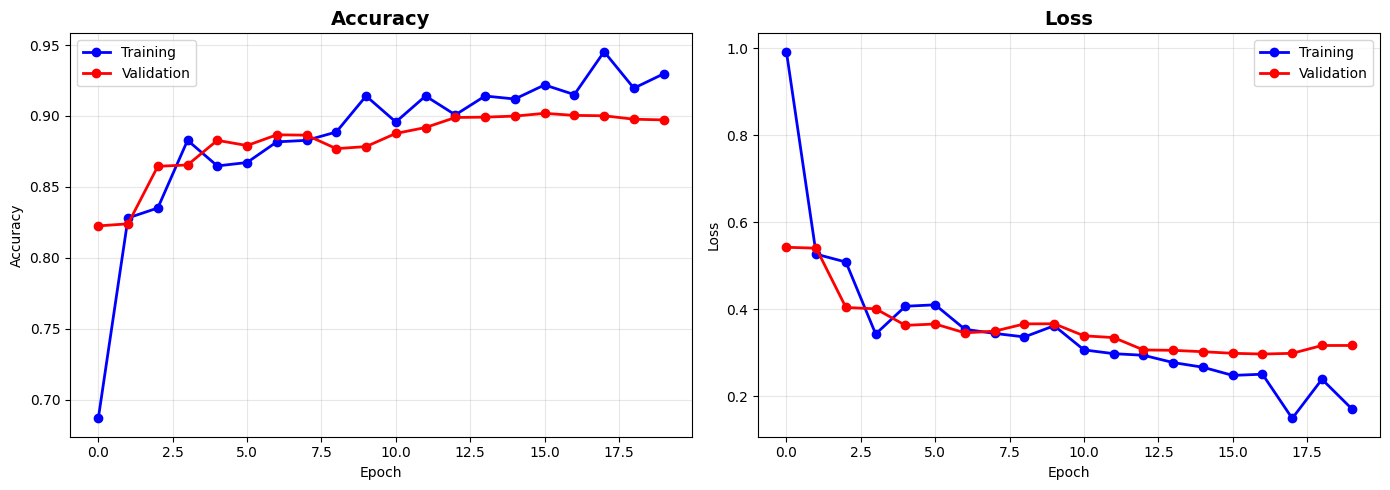


📊 Creating confusion matrix...
32/32 ━━━━━━━━━━━━━━━━━━━━ 18s 417ms/step


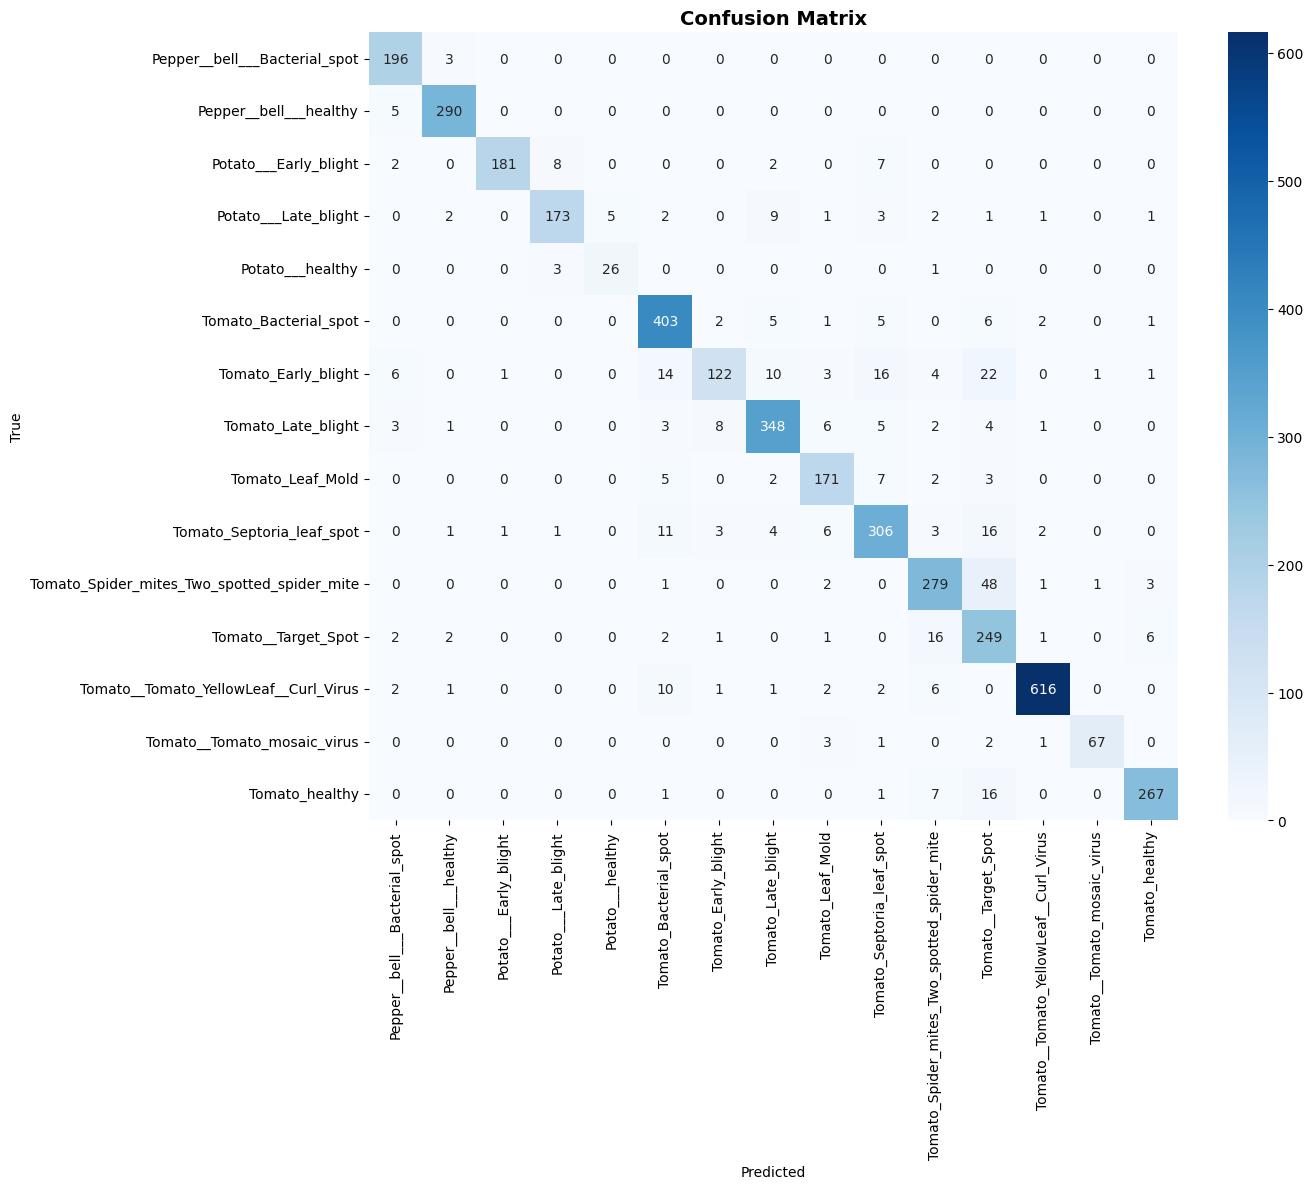


📋 Classification Report:
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.91      0.98      0.94       199
                     Pepper__bell___healthy       0.97      0.98      0.97       295
                      Potato___Early_blight       0.99      0.91      0.95       200
                       Potato___Late_blight       0.94      0.86      0.90       200
                           Potato___healthy       0.84      0.87      0.85        30
                      Tomato_Bacterial_spot       0.89      0.95      0.92       425
                        Tomato_Early_blight       0.89      0.61      0.72       200
                         Tomato_Late_blight       0.91      0.91      0.91       381
                           Tomato_Leaf_Mold       0.87      0.90      0.89       190
                  Tomato_Septoria_leaf_spot       0.87      0.86      0.87       354
Tomato_Spider_mites_Two_spotted_spider

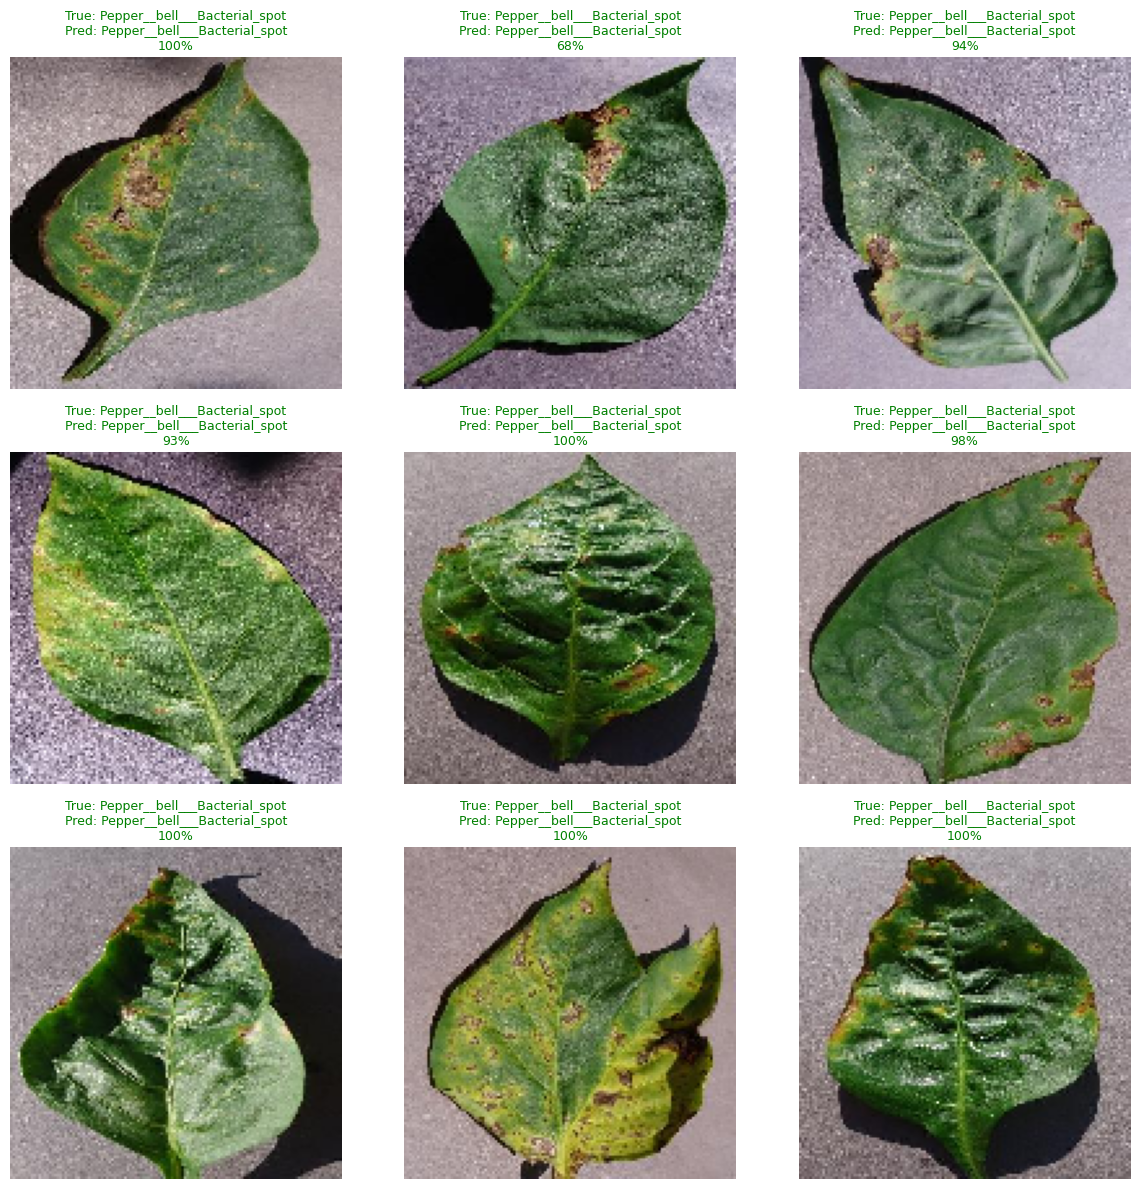


🎉 ALL DONE!
⏱️ Training time: 87.6 minutes
🎯 Accuracy: 90.19%

📦 Files saved:
   ✅ plant_disease_model_final.keras
   ✅ plant_disease_model_final.h5
   ✅ class_labels.json
   ✅ training_history.png
   ✅ confusion_matrix.png
   ✅ classification_report.txt
   ✅ sample_predictions.png

🌟 MODEL READY TO USE!


In [ ]:
# ===== SUPER FAST TRAINING - MAXIMUM SPEED =====

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.applications import MobileNetV2
from sklearn.metrics import classification_report, confusion_matrix
import json
from datetime import datetime

print("🚀 MAXIMUM SPEED VERSION - OPTIMIZED FOR FAST TRAINING")
print("=" * 70)

# Check GPU
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"✅ GPU ENABLED: {gpus[0].name}")
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError:
        print("   (GPU already initialized - no problem!)")
else:
    print("❌ NO GPU! This will be slow!")

# ===== KEY CHANGES FOR SPEED =====
DATASET_PATH = '/content/drive/MyDrive/INTERNSHIP FILE AICTE/PlantVillage_Dataset'
IMG_HEIGHT = 128  # REDUCED from 224 - Much faster!
IMG_WIDTH = 128   # REDUCED from 224 - Much faster!
BATCH_SIZE = 128  # INCREASED from 64 - Process more at once!
EPOCHS = 20       # Reduced epochs
VALIDATION_SPLIT = 0.2

print(f"\n⚡ SPEED SETTINGS:")
print(f"   Image Size: {IMG_HEIGHT}x{IMG_WIDTH} (smaller = faster)")
print(f"   Batch Size: {BATCH_SIZE} (bigger = faster)")
print(f"   Epochs: {EPOCHS}")

# ===== MINIMAL AUGMENTATION FOR SPEED =====
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    horizontal_flip=True,
    validation_split=VALIDATION_SPLIT
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=VALIDATION_SPLIT
)

print("\n📂 Loading dataset...")

train_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

validation_generator = val_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

class_labels = list(train_generator.class_indices.keys())
num_classes = len(class_labels)

steps_per_epoch = train_generator.samples // BATCH_SIZE
val_steps = validation_generator.samples // BATCH_SIZE

print(f"✅ Data loaded!")
print(f"   Training: {train_generator.samples} images")
print(f"   Validation: {validation_generator.samples} images")
print(f"   Classes: {num_classes}")
print(f"   Steps per epoch: {steps_per_epoch} (MUCH LESS!)")

# ===== BUILD LIGHTWEIGHT MODEL =====
print("\n🏗️ Building lightweight model...")

base_model = MobileNetV2(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    include_top=False,
    weights='imagenet',
    alpha=0.75  # Use lighter version of MobileNet
)

base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Lightweight model built!")
print(f"   Parameters: {model.count_params():,}")

# ===== CALLBACKS =====
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=4,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    '/content/best_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=0.00001,
    verbose=1
)

callbacks = [early_stop, checkpoint, reduce_lr]

# ===== TRAIN =====
print("\n" + "=" * 70)
print("🚀 STARTING TRAINING - FAST MODE!")
print("=" * 70)
print(f"⏱️ Expected: 5-8 minutes total")
print(f"⏱️ Each epoch: 15-30 seconds")
print("\n")

start_time = datetime.now()

history = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=EPOCHS,
    validation_data=validation_generator,
    validation_steps=val_steps,
    callbacks=callbacks,
    verbose=1
)

end_time = datetime.now()
training_duration = (end_time - start_time).total_seconds() / 60

print("\n✅ TRAINING DONE!")
print(f"⏱️ Time taken: {training_duration:.1f} minutes")

# ===== EVALUATE =====
val_loss, val_accuracy = model.evaluate(validation_generator, steps=val_steps, verbose=1)

print("\n" + "=" * 70)
print(f"🎯 ACCURACY: {val_accuracy * 100:.2f}%")
print("=" * 70)

# ===== SAVE MODEL =====
print("\n💾 Saving model...")

model.save('/content/drive/MyDrive/INTERNSHIP FILE AICTE/plant_disease_model_final.keras')
model.save('/content/drive/MyDrive/INTERNSHIP FILE AICTE/plant_disease_model_final.h5')
model.save('/content/plant_disease_model_final.h5')

with open('/content/drive/MyDrive/INTERNSHIP FILE AICTE/class_labels.json', 'w') as f:
    json.dump(class_labels, f, indent=2)

print("✅ Model saved!")

# ===== PLOTS =====
print("\n📊 Creating plots...")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], 'b-o', label='Training', linewidth=2)
axes[0].plot(history.history['val_accuracy'], 'r-o', label='Validation', linewidth=2)
axes[0].set_title('Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'], 'b-o', label='Training', linewidth=2)
axes[1].plot(history.history['val_loss'], 'r-o', label='Validation', linewidth=2)
axes[1].set_title('Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/INTERNSHIP FILE AICTE/training_history.png', dpi=200)
plt.savefig('/content/training_history.png', dpi=200)
plt.show()

# ===== CONFUSION MATRIX =====
print("\n📊 Creating confusion matrix...")

validation_generator.reset()
y_pred_probs = model.predict(validation_generator, steps=val_steps, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = validation_generator.classes[:len(y_pred)]

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/INTERNSHIP FILE AICTE/confusion_matrix.png', dpi=200)
plt.savefig('/content/confusion_matrix.png', dpi=200)
plt.show()

# ===== REPORT =====
print("\n📋 Classification Report:")
report = classification_report(y_true, y_pred, target_names=class_labels)
print(report)

with open('/content/drive/MyDrive/INTERNSHIP FILE AICTE/classification_report.txt', 'w') as f:
    f.write(f"Training Time: {training_duration:.1f} min\n")
    f.write(f"Accuracy: {val_accuracy * 100:.2f}%\n\n")
    f.write(report)

# ===== SAMPLE PREDICTIONS =====
print("\n🧪 Sample predictions...")

validation_generator.reset()
test_images, test_labels = next(validation_generator)
predictions = model.predict(test_images[:9])

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.ravel()

for i in range(9):
    axes[i].imshow(test_images[i])
    true_label = class_labels[np.argmax(test_labels[i])]
    pred_label = class_labels[np.argmax(predictions[i])]
    confidence = np.max(predictions[i]) * 100

    color = 'green' if true_label == pred_label else 'red'
    axes[i].set_title(f'True: {true_label}\nPred: {pred_label}\n{confidence:.0f}%',
                     color=color, fontsize=9)
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/INTERNSHIP FILE AICTE/sample_predictions.png', dpi=200)
plt.show()

# ===== SUMMARY =====
print("\n" + "=" * 70)
print("🎉 ALL DONE!")
print("=" * 70)
print(f"⏱️ Training time: {training_duration:.1f} minutes")
print(f"🎯 Accuracy: {val_accuracy * 100:.2f}%")
print("\n📦 Files saved:")
print("   ✅ plant_disease_model_final.keras")
print("   ✅ plant_disease_model_final.h5")
print("   ✅ class_labels.json")
print("   ✅ training_history.png")
print("   ✅ confusion_matrix.png")
print("   ✅ classification_report.txt")
print("   ✅ sample_predictions.png")
print("\n🌟 MODEL READY TO USE!")
print("=" * 70)

🔄 RETRAINING MODEL - TENSORFLOW 2.16+ COMPATIBLE
TensorFlow version: 2.19.0
Found 16516 images belonging to 15 classes.
Found 4122 images belonging to 15 classes.

✅ Data loaded!
   Training: 16516 images
   Validation: 4122 images
   Classes: 15

🏗️ Building simple CNN model...
✅ Model built!
   Parameters: 2,784,719

🚀 STARTING TRAINING


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 941ms/step - accuracy: 0.3987 - loss: 2.2937
Epoch 1: val_accuracy improved from -inf to 0.15163, saving model to /content/best_model_new.keras
130/130 ━━━━━━━━━━━━━━━━━━━━ 801s 6s/step - accuracy: 0.3995 - loss: 2.2892 - val_accuracy: 0.1516 - val_loss: 9.3444 - learning_rate: 0.0010
Epoch 2/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 915ms/step - accuracy: 0.6346 - loss: 1.1821
Epoch 2: val_accuracy did not improve from 0.15163
130/130 ━━━━━━━━━━━━━━━━━━━━ 133s 1s/step - accuracy: 0.6348 - loss: 1.1817 - val_accuracy: 0.1460 - val_loss: 8.0098 - learning_rate: 0.0010
Epoch 3/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 903ms/step - accuracy: 0.7203 - loss: 0.9366
Epoch 3: val_accuracy improved from 0.15163 to 0.29088, saving model to /content/best_model_new.keras
130/130 ━━━━━━━━━━━━━━━━━━━━ 132s 1s/step - accuracy: 0.7204 - loss: 0.9363 - val_accuracy: 0.2909 - val_loss: 5.8009 - learning_rate: 0.0010
Epoch 4/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 900ms/step - ac

✅ Model saved in both .keras and .h5 formats!


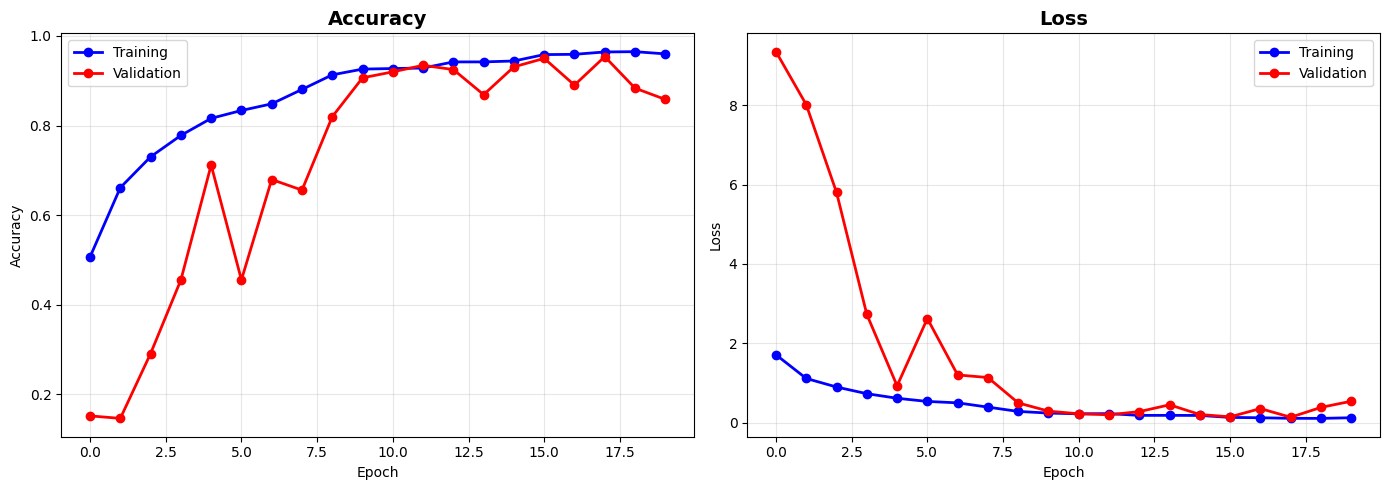


🎉 ALL DONE!
⏱️ Training time: 55.1 minutes
🎯 Accuracy: 95.39%

📦 Files saved:
   ✅ plant_disease_model_compatible.keras
   ✅ plant_disease_model_compatible.h5
   ✅ class_labels.json

📥 DOWNLOAD plant_disease_model_compatible.h5 from Colab!


In [2]:
# ===== RETRAIN MODEL - COMPATIBLE WITH TENSORFLOW 2.16+ =====
# Run this in Google Colab

import os
import numpy as np
import matplotlib.pyplot as plt
import json
from datetime import datetime

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

print("=" * 70)
print("🔄 RETRAINING MODEL - TENSORFLOW 2.16+ COMPATIBLE")
print("=" * 70)
print(f"TensorFlow version: {tf.__version__}")

# Parameters
DATASET_PATH = '/content/drive/MyDrive/INTERNSHIP FILE AICTE/PlantVillage_Dataset'
IMG_HEIGHT = 128
IMG_WIDTH = 128
BATCH_SIZE = 128
EPOCHS = 20
VALIDATION_SPLIT = 0.2

# Data generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    horizontal_flip=True,
    validation_split=VALIDATION_SPLIT
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=VALIDATION_SPLIT
)

train_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

validation_generator = val_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

class_labels = list(train_generator.class_indices.keys())
num_classes = len(class_labels)

print(f"\n✅ Data loaded!")
print(f"   Training: {train_generator.samples} images")
print(f"   Validation: {validation_generator.samples} images")
print(f"   Classes: {num_classes}")

# Build SIMPLE CNN model (NO transfer learning to avoid compatibility issues)
print("\n🏗️ Building simple CNN model...")

model = keras.Sequential([
    # Block 1
    layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Block 2
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Block 3
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Block 4
    layers.Conv2D(256, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Dense layers
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Model built!")
print(f"   Parameters: {model.count_params():,}")

# Callbacks
early_stop = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1)
checkpoint = ModelCheckpoint('/content/best_model_new.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=0.00001, verbose=1)
callbacks = [early_stop, checkpoint, reduce_lr]

# Train
print("\n" + "=" * 70)
print("🚀 STARTING TRAINING")
print("=" * 70)

start_time = datetime.now()

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=validation_generator,
    callbacks=callbacks,
    verbose=1
)

end_time = datetime.now()
training_duration = (end_time - start_time).total_seconds() / 60

print("\n✅ TRAINING DONE!")
print(f"⏱️ Time: {training_duration:.1f} minutes")

# Evaluate
val_loss, val_accuracy = model.evaluate(validation_generator, verbose=1)
print(f"\n🎯 Validation Accuracy: {val_accuracy * 100:.2f}%")

# Save model in BOTH formats
print("\n💾 Saving model...")

# Save as .keras (new format - recommended)
model.save('/content/drive/MyDrive/INTERNSHIP FILE AICTE/plant_disease_model_compatible.keras')
model.save('/content/plant_disease_model_compatible.keras')

# Save as .h5 (old format - for compatibility)
model.save('/content/drive/MyDrive/INTERNSHIP FILE AICTE/plant_disease_model_compatible.h5')
model.save('/content/plant_disease_model_compatible.h5')

# Save class labels
with open('/content/drive/MyDrive/INTERNSHIP FILE AICTE/class_labels.json', 'w') as f:
    json.dump(class_labels, f, indent=2)

with open('/content/class_labels.json', 'w') as f:
    json.dump(class_labels, f, indent=2)

print("✅ Model saved in both .keras and .h5 formats!")

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], 'b-o', label='Training', linewidth=2)
axes[0].plot(history.history['val_accuracy'], 'r-o', label='Validation', linewidth=2)
axes[0].set_title('Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'], 'b-o', label='Training', linewidth=2)
axes[1].plot(history.history['val_loss'], 'r-o', label='Validation', linewidth=2)
axes[1].set_title('Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/INTERNSHIP FILE AICTE/training_history_new.png', dpi=200)
plt.show()

print("\n" + "=" * 70)
print("🎉 ALL DONE!")
print("=" * 70)
print(f"⏱️ Training time: {training_duration:.1f} minutes")
print(f"🎯 Accuracy: {val_accuracy * 100:.2f}%")
print("\n📦 Files saved:")
print("   ✅ plant_disease_model_compatible.keras")
print("   ✅ plant_disease_model_compatible.h5")
print("   ✅ class_labels.json")
print("\n📥 DOWNLOAD plant_disease_model_compatible.h5 from Colab!")
print("=" * 70)